In [145]:
#!C:\Program Files\Python313\python.exe

"""
PROJECT 3 — Social Media Mining (COMP3800 P03)
Fall 2025
"""

"""
TASK 1
"""

import pandas as pd
import os

# Step 1: Merge 14 CSV files into one DataFrame
DATA_DIR = r"C:\Users\jyoon1\Downloads\COMP3800F25\COMP3800F25"
stems = ["guvnor","jisoo","jupiter","kyron","maria","matthew",
         "moriael","tyler","aique","alex","ana","brailey","dylan","george"]

# Read and combine all CSVs
dfs = [pd.read_csv(os.path.join(DATA_DIR, f"{stem}.csv")) for stem in stems]
df = pd.concat(dfs, ignore_index=True)

# Save merged file
output_file = os.path.join(DATA_DIR, "comp3800f25_tweets.csv")
df.to_csv(output_file, index=False, encoding="utf-8")

In [146]:
# Step 2: Keep only specific common columns
common_cols = [
    "id","url","twitterUrl","text","source","retweetCount","replyCount",
    "likeCount","quoteCount","viewCount","createdAt","lang","bookmarkCount",
    "isReply","inReplyToId","conversationId","inReplyToUsername","isPinned",
    "isConversationControlled","isQuote","type"
]
df = df[[col for col in common_cols if col in df.columns]]

# Step 3: Remove mock tweets
df = df[~df["type"].str.contains("mock_tweet", na=False)]
df = df[df["type"] == "tweet"]

# Step 4: Remove duplicated rows based on specific columns
df = df.drop_duplicates(subset=[
    "id","url","twitterUrl","text","source","retweetCount","replyCount",
    "likeCount","quoteCount","viewCount","createdAt","lang","bookmarkCount",
    "isReply","inReplyToId","conversationId","inReplyToUsername","isPinned",
    "isConversationControlled","isQuote"
])

In [147]:
# Step 5: Print final shape
print(f"Final Shape: ({df.shape[0]}, {df.shape[1]})")

Final Shape: (20962, 21)


In [148]:
"""
TASK 2
"""

# Step 1 — Export keywords from Excel to plain text

import pandas as pd

# ✅ Use read_csv instead of read_excel
keyword_df = pd.read_csv("C:/Users/jyoon1/Downloads/COMP3800F25/COMP3800F25/COMP3800F25S01Keywords(Sheet1).csv")

# Drop the first column (colleagues' names) and keep only 'keyword'
keyword_only = keyword_df["keyword"].dropna()

# Export to plain text file (one keyword per line, no header/index)
keyword_only.to_csv("comp3800f25_keywords.txt", index=False, header=False)

print("✅ Exported keywords to comp3800f25_keywords.txt")

✅ Exported keywords to comp3800f25_keywords.txt


In [149]:
# Step 2 — Load keywords from CSV, normalize, ensure uniqueness

# Load keywords CSV version
keywords_csv = pd.read_csv("C:/Users/jyoon1/Downloads/COMP3800F25/COMP3800F25/COMP3800F25S01Keywords(Sheet1).csv")

# Normalize: lowercase, strip whitespace, ensure uniqueness
keywords = keywords_csv["keyword"].dropna().unique()
keywords = [kw.strip().lower() for kw in keywords]
keywords_set = set(keywords)

print(f"Total unique keywords: {len(keywords_set)}")
list(keywords_set)[:10]  # preview first 10




Total unique keywords: 345


['performance-metric',
 'software-engineer',
 'benchmarking',
 'decision-tree',
 'legacy-migration',
 'test-automation',
 'infrastructure',
 'outsourcing',
 'feature-flag',
 'digital-transformation']

In [150]:
# Step 3 — Count keyword occurrences in tweets

import pandas as pd
import re

# Load keywords (FIXED PATH) ===
keyword_path = "C:/Users/jyoon1/Downloads/COMP3800F25/COMP3800F25/COMP3800F25S01Keywords(Sheet1).csv"
keywords_df = pd.read_csv(keyword_path)

# Normalize and extract keyword set
keywords = keywords_df["keyword"].dropna().unique()
keywords = [kw.strip().lower() for kw in keywords]
keywords_set = set(keywords)

# Load tweets CSV ===
tweets_path = "C:/Users/jyoon1/Downloads/COMP3800F25/COMP3800F25/comp3800f25_tweets.csv"
tweets = pd.read_csv(tweets_path)

# Normalize tweet text
tweets["text_norm"] = tweets["text"].astype(str).str.lower()

# Count keyword frequencies ===
keyword_counts = {}
for kw in keywords_set:
    keyword_counts[kw] = tweets["text_norm"].str.contains(
        r"\b" + re.escape(kw) + r"\b", regex=True
    ).sum()

# Build frequency table ===
kw_df = pd.DataFrame(keyword_counts.items(), columns=["keyword", "count"]) \
         .sort_values("count", ascending=False)

kw_df.head()


C:\Users\local_jyoon1\Temp\ipykernel_5464\3582196955.py:17: DtypeWarning: Columns (14,18,19,25,29,30,33,36,39,42,45,48,51,54,57,60,63,66,69,72,75,78,81,84,87,90,93,94,95,98,99,100,103,104,105,108,112,113,117,118,122,123,127,128,132,133,137,138,142,143,147,148,152,153,157,158,162,163,167,168,172,173,177,178,182,183,184,185,186,187,188,189,190,191,193,194,195,197,198,199,201,202,203,205,206,207,209,210,211,248,249,250,251,252,253,278,279,284,285,287,288,290,291,293,294,296,297,299,300,302,303,304,305,365,366,367,368,369,370,395,396,419,420,421,422,482,483,484,485,486,487,512,513,536,537,538,539,599,600,601,602,603,604,629,630,652,674,677,679,701,704,706,730,731,733,758,760,782,785,787,809,811,812,814,836,839,841,863,865,866,868,890,892,893,895,917,922,944,949,971,976,998,1000,1001,1003,1025,1027,1028,1030,1052,1054,1055,1057,1079,1082,1084,1109,1111,1133,1136,1138,1160,1165,1187,1192,1214,1219,1241,1243,1244,1246,1268,1270,1271,1273,1295,1297,1298,1300,1315,1320,1321,1323,1324,1326,1328,

,keyword,count
187,data,1823
128,automation,972
300,design,853
183,innovation,822
191,techlayoffs,798


<Figure size 1200x600 with 0 Axes>

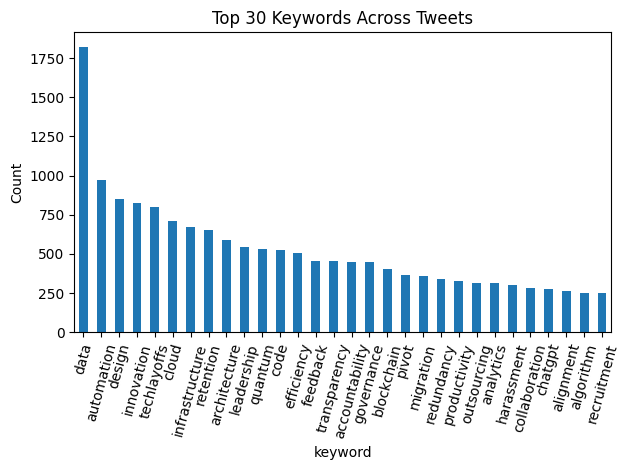

In [151]:
#Step 4a — Bar plot of top 30 keywords

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
kw_df.head(30).plot(kind="bar", x="keyword", y="count", legend=False)
plt.title("Top 30 Keywords Across Tweets")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

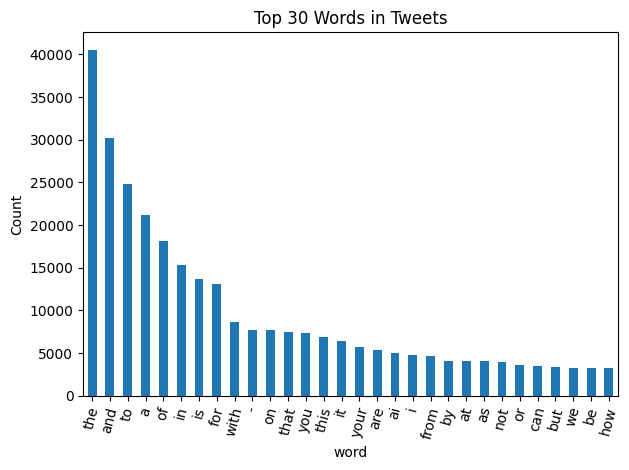

In [152]:
#Step 4b — Bar plot of most frequent words/stems

from collections import Counter

all_words = " ".join(tweets["text_norm"].tolist()).split()
word_counts = Counter(all_words)
word_df = pd.DataFrame(word_counts.most_common(30), columns=["word","count"])

plt.figure(figsize=(12,6))
word_df.plot(kind="bar", x="word", y="count", legend=False)
plt.title("Top 30 Words in Tweets")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [153]:
#Step 4c — Identify unused keywords

never_used = kw_df[kw_df["count"] == 0]["keyword"].tolist()
print("Keywords never appearing in any tweet:")
print(never_used)

Keywords never appearing in any tweet:
['niche-markets', 'platform-engineer', 'team-scaling', 'empowerment-culture', 'future-of?work', 'job-stress', 'workflow-orchestration', 'gamble-tech', 'configuration-management', 'growth-hacking', 'business-intelligence', 'pivot-strategy', 'corporate-culture', 'innovation-lab', 'skill-gap', 'ethical-ai', 'system-administrator', 'tooling-ecosystem', 'hiring-pipeline', 'edge-intelligence', 'legacy-system', 'experience-level', 'job-fulfilment', 'outsourcing-strategy', 'green-it', 'tech-optimism', 'quality-assurance', 'talent-acquisition', 'network-latency', 'ethical-engineering', 'technical-debt', 'cloud-computing', 'skill-development', 'system-architecture', 'user-centred-design', 'deployment-pipeline', 'data-mining', 'hiring-freeze', 'human-capital', 'encryption-policy', 'scalability-challenge', 'job-satisfaction', 'continuous-delivery', 'knowledge-transfer', 'industry-trend', 'shared-responsibility', 'schedule-flexibility', 'data-engineer', 'runti

In [154]:
#Step 4d — Identify clusters

clusters = {
    "layoffs/hiring": ["layoff","hiring-freeze","hiring-pipeline","hiring-surge"],
    "AI/ML": ["artificial-intelligence","machine-learning","deep-learning","chatgpt","llm"],
    "burnout/work": ["burnout","work-life-balance","job-stress","workplace-culture"],
    "remote/cloud": ["remote-work","cloud","cloud-computing","multi-cloud"],
    "quantum": ["quantum","quantumcomputing","qnn","qubit"]
}

for cluster, kws in clusters.items():
    total = sum(keyword_counts.get(kw,0) for kw in kws)
    print(f"Cluster '{cluster}' total mentions: {total}")

Cluster 'layoffs/hiring' total mentions: 111
Cluster 'AI/ML' total mentions: 279
Cluster 'burnout/work' total mentions: 190
Cluster 'remote/cloud' total mentions: 782
Cluster 'quantum' total mentions: 988


In [155]:
"""
TASK 3~5 Topic: “Are tweets mentioning layoffs more likely to go viral than tweets mentioning hiring or job openings?”
"""

"""
TASK 3
"""

# Step 1 — Create Binary Indicator Variables

import pandas as pd
import re

# Load tweets dataset
tweets = pd.read_csv("C:/Users/jyoon1/Downloads/COMP3800F25/COMP3800F25/comp3800f25_tweets.csv")

# Normalize text
tweets["text_norm"] = tweets["text"].astype(str).str.lower()

# Define keyword groups
layoff_keywords = ["layoff", "hiring-freeze", "techlayoffs"]
hiring_keywords = ["hiring", "job-openings", "hiring-surge"]

# Binary indicators
tweets["is_layoff_related"] = tweets["text_norm"].apply(lambda x: any(kw in x for kw in layoff_keywords))
tweets["is_hiring_related"] = tweets["text_norm"].apply(lambda x: any(kw in x for kw in hiring_keywords))

print("Layoff-related tweets:", tweets["is_layoff_related"].sum())
print("Hiring-related tweets:", tweets["is_hiring_related"].sum())

C:\Users\local_jyoon1\Temp\ipykernel_5464\1887801432.py:15: DtypeWarning: Columns (14,18,19,25,29,30,33,36,39,42,45,48,51,54,57,60,63,66,69,72,75,78,81,84,87,90,93,94,95,98,99,100,103,104,105,108,112,113,117,118,122,123,127,128,132,133,137,138,142,143,147,148,152,153,157,158,162,163,167,168,172,173,177,178,182,183,184,185,186,187,188,189,190,191,193,194,195,197,198,199,201,202,203,205,206,207,209,210,211,248,249,250,251,252,253,278,279,284,285,287,288,290,291,293,294,296,297,299,300,302,303,304,305,365,366,367,368,369,370,395,396,419,420,421,422,482,483,484,485,486,487,512,513,536,537,538,539,599,600,601,602,603,604,629,630,652,674,677,679,701,704,706,730,731,733,758,760,782,785,787,809,811,812,814,836,839,841,863,865,866,868,890,892,893,895,917,922,944,949,971,976,998,1000,1001,1003,1025,1027,1028,1030,1052,1054,1055,1057,1079,1082,1084,1109,1111,1133,1136,1138,1160,1165,1187,1192,1214,1219,1241,1243,1244,1246,1268,1270,1271,1273,1295,1297,1298,1300,1315,1320,1321,1323,1324,1326,1328,

Layoff-related tweets: 1096
Hiring-related tweets: 831


In [156]:
# Step 2 — Sentiment Analysis (TextBlob)

from textblob import TextBlob

# Sentiment polarity
tweets["sentiment_tb"] = tweets["text_norm"].apply(lambda x: TextBlob(x).sentiment.polarity)

# Quick summary
print("Average sentiment (layoff tweets):", tweets.loc[tweets["is_layoff_related"], "sentiment_tb"].mean())
print("Average sentiment (hiring tweets):", tweets.loc[tweets["is_hiring_related"], "sentiment_tb"].mean())

Average sentiment (layoff tweets): 0.02517319455658017
Average sentiment (hiring tweets): 0.11061590276904974


In [157]:
# Step 3 - Sentiment Analysis (VADER, optional)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
tweets["sentiment_vader"] = tweets["text_norm"].apply(lambda x: analyzer.polarity_scores(x)["compound"])

print("Average VADER sentiment (layoff tweets):", tweets.loc[tweets["is_layoff_related"], "sentiment_vader"].mean())
print("Average VADER sentiment (hiring tweets):", tweets.loc[tweets["is_hiring_related"], "sentiment_vader"].mean())

Average VADER sentiment (layoff tweets): -0.05897892335766422
Average VADER sentiment (hiring tweets): 0.2563821901323706


C:\Users\local_jyoon1\Temp\ipykernel_5464\1136519930.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tweets["createdAt"] = pd.to_datetime(tweets["createdAt"], errors="coerce")


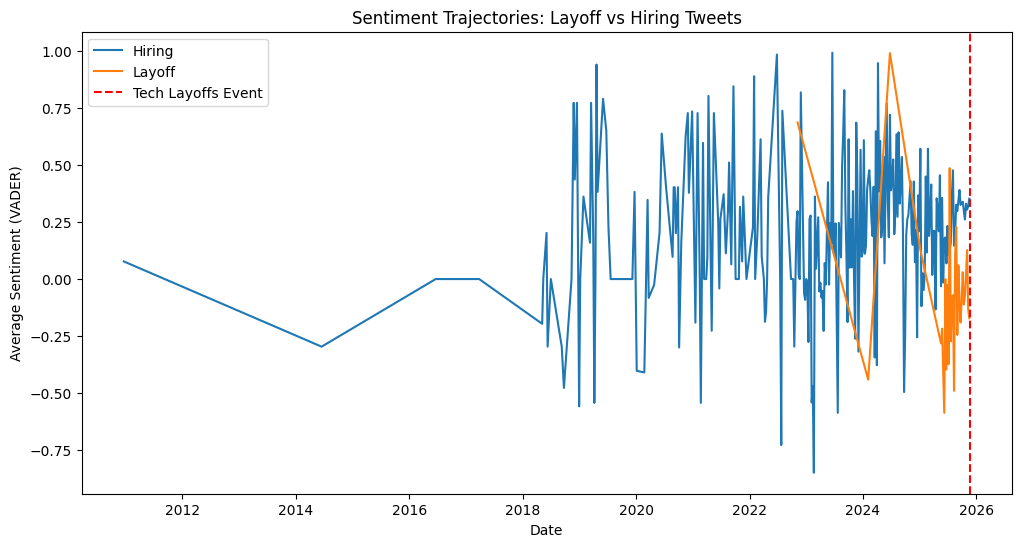

In [158]:
# Step 4 - Sentiment Trajectories Over Time

# Convert createdAt to datetime
tweets["createdAt"] = pd.to_datetime(tweets["createdAt"], errors="coerce")

# Weekly average sentiment
sentiment_traj = tweets.groupby([pd.Grouper(key="createdAt", freq="W"), "is_layoff_related"])["sentiment_vader"].mean().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
for label, df_sub in sentiment_traj.groupby("is_layoff_related"):
    plt.plot(df_sub["createdAt"], df_sub["sentiment_vader"], label="Layoff" if label else "Hiring")
plt.axvline(pd.to_datetime("2025-11-18"), color="red", linestyle="--", label="Tech Layoffs Event")
plt.title("Sentiment Trajectories: Layoff vs Hiring Tweets")
plt.xlabel("Date")
plt.ylabel("Average Sentiment (VADER)")
plt.legend()
plt.show()

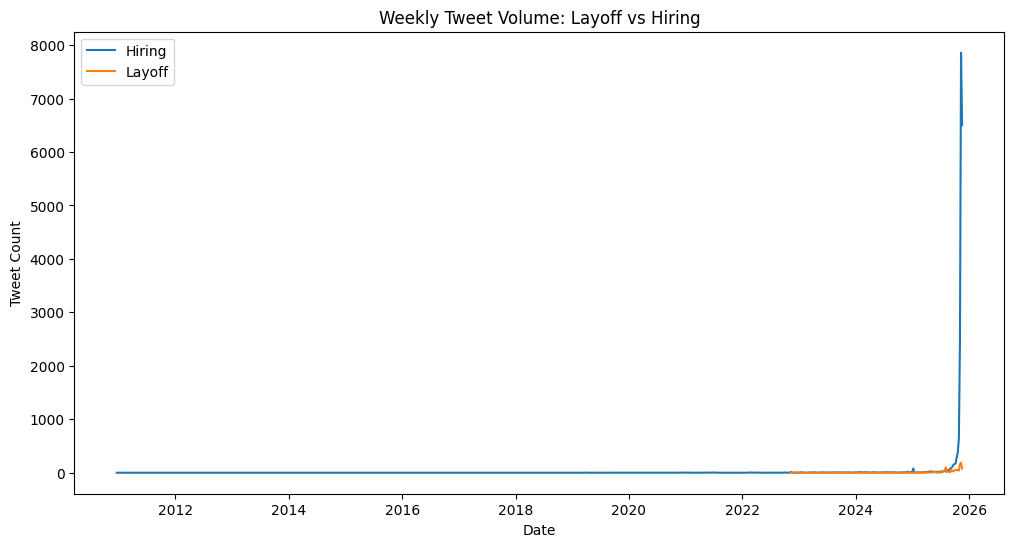

In [159]:
"""
TASK 4
"""

# Step 1 - Tweet Volume Over Time

import matplotlib.pyplot as plt

# Ensure datetime
tweets["createdAt"] = pd.to_datetime(tweets["createdAt"], errors="coerce")

# Weekly tweet volume by category
volume_traj = tweets.groupby([pd.Grouper(key="createdAt", freq="W"), "is_layoff_related"])["id"].count().reset_index()

plt.figure(figsize=(12,6))
for label, df_sub in volume_traj.groupby("is_layoff_related"):
    plt.plot(df_sub["createdAt"], df_sub["id"], label="Layoff" if label else "Hiring")
plt.title("Weekly Tweet Volume: Layoff vs Hiring")
plt.xlabel("Date")
plt.ylabel("Tweet Count")
plt.legend()
plt.show()

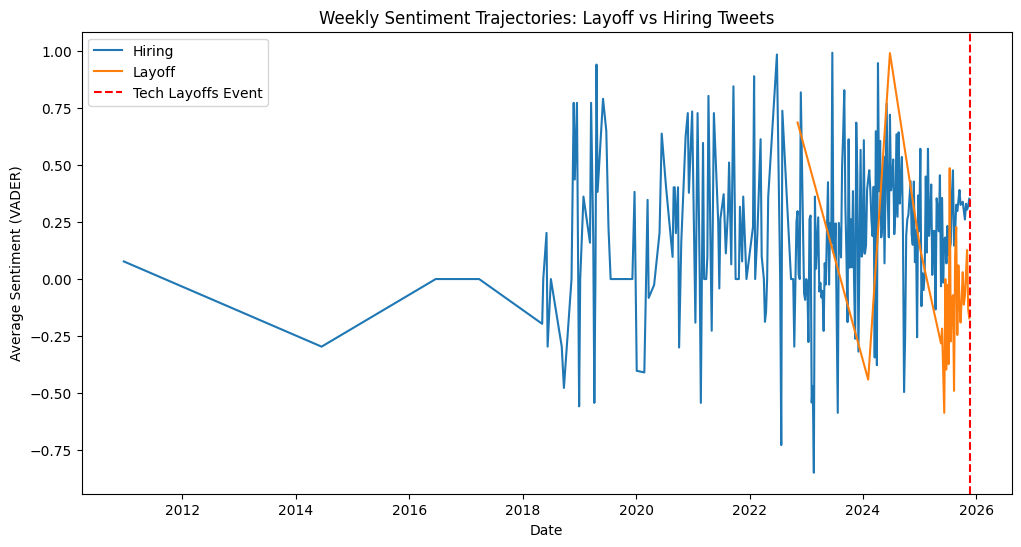

In [160]:
# Step 2 - Sentiment Over Time

# Weekly average sentiment by category
sentiment_traj = tweets.groupby([pd.Grouper(key="createdAt", freq="W"), "is_layoff_related"])["sentiment_vader"].mean().reset_index()

plt.figure(figsize=(12,6))
for label, df_sub in sentiment_traj.groupby("is_layoff_related"):
    plt.plot(df_sub["createdAt"], df_sub["sentiment_vader"], label="Layoff" if label else "Hiring")
plt.axvline(pd.to_datetime("2025-11-18"), color="red", linestyle="--", label="Tech Layoffs Event")
plt.title("Weekly Sentiment Trajectories: Layoff vs Hiring Tweets")
plt.xlabel("Date")
plt.ylabel("Average Sentiment (VADER)")
plt.legend()
plt.show()

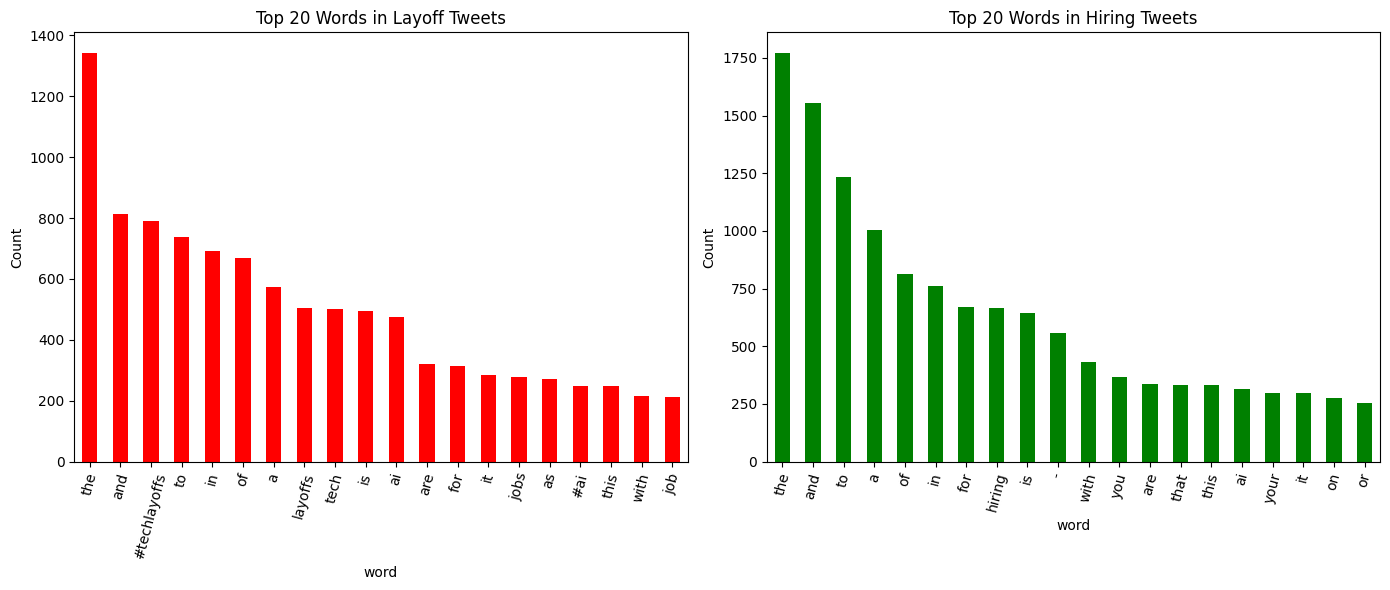

In [161]:
"""
TASK 5
"""

# Step 1 — Bar Charts of Top Words/Stems

import matplotlib.pyplot as plt
from collections import Counter

# Tokenize words
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

# Separate categories
layoff_words = " ".join(tweets.loc[tweets["is_layoff_related"], "text_norm"]).split()
hiring_words = " ".join(tweets.loc[tweets["is_hiring_related"], "text_norm"]).split()

# Count frequencies
layoff_counts = Counter(layoff_words)
hiring_counts = Counter(hiring_words)

# Convert to DataFrame
layoff_df = pd.DataFrame(layoff_counts.most_common(20), columns=["word","count"])
hiring_df = pd.DataFrame(hiring_counts.most_common(20), columns=["word","count"])

# Plot
fig, axes = plt.subplots(1,2, figsize=(14,6))
layoff_df.plot(kind="bar", x="word", y="count", ax=axes[0], legend=False, color="red")
axes[0].set_title("Top 20 Words in Layoff Tweets")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=75)

hiring_df.plot(kind="bar", x="word", y="count", ax=axes[1], legend=False, color="green")
axes[1].set_title("Top 20 Words in Hiring Tweets")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

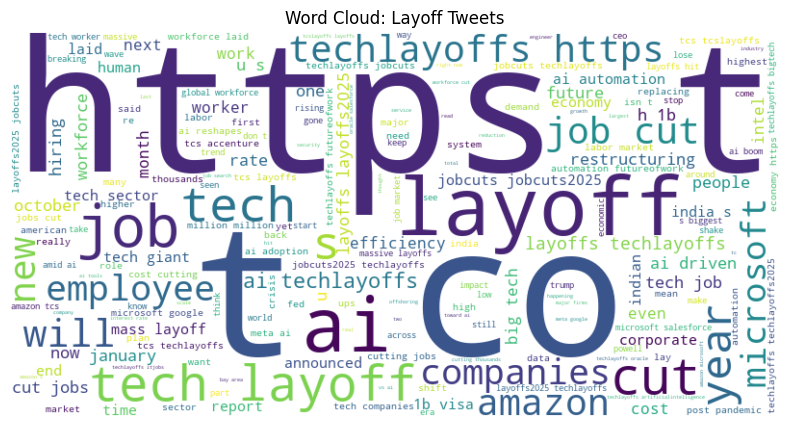

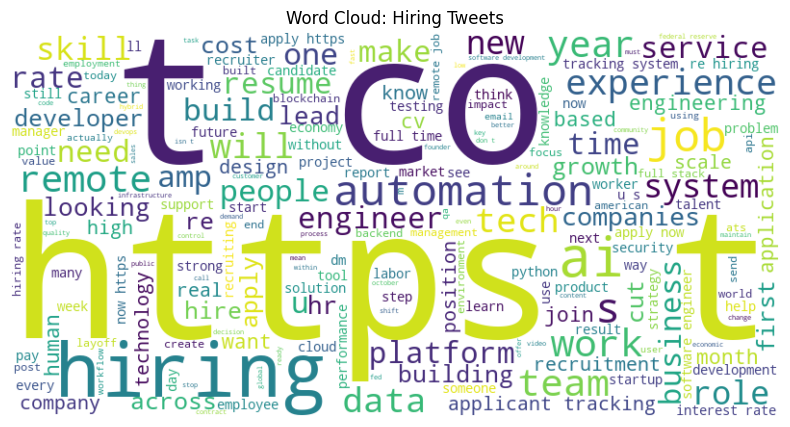

In [162]:
# Step 2 — Word Clouds

from wordcloud import WordCloud

# Layoff word cloud
layoff_wc = WordCloud(width=800, height=400, background_color="white").generate(" ".join(layoff_words))
plt.figure(figsize=(10,5))
plt.imshow(layoff_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Layoff Tweets")
plt.show()

# Hiring word cloud
hiring_wc = WordCloud(width=800, height=400, background_color="white").generate(" ".join(hiring_words))
plt.figure(figsize=(10,5))
plt.imshow(hiring_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Hiring Tweets")
plt.show()

In [163]:
"""
TASK 6 Choose One of the following prediction task
Topic: Predict high-engagement tweets. Binary classification: high_engagement = 1 if
retweetCount is in the top 20 percentile.
"""

# Step 1 - Feature Engineering

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Define high engagement (top 20% retweets)
threshold = tweets["retweetCount"].quantile(0.8)
tweets["high_engagement"] = (tweets["retweetCount"] >= threshold).astype(int)

# Features: text + sentiment + binary indicators
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_text = vectorizer.fit_transform(tweets["text_norm"])

X = pd.DataFrame(X_text.toarray(), columns=vectorizer.get_feature_names_out())
X["sentiment_vader"] = tweets["sentiment_vader"]
X["is_layoff_related"] = tweets["is_layoff_related"].astype(int)
X["is_hiring_related"] = tweets["is_hiring_related"].astype(int)

y = tweets["high_engagement"]

In [164]:
# Step 2 — Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [165]:
# Step 3 — Model Training

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [166]:
# Step 4 — Evaluation

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      3444
           1       0.72      0.29      0.41       863

    accuracy                           0.83      4307
   macro avg       0.78      0.63      0.66      4307
weighted avg       0.82      0.83      0.80      4307

ROC-AUC: 0.8334366247982956


### Task 6 - Prediction Modeling

For our prediction task to determine whether tweets that relate to layoffs would have high engagement, we created a high-engagement prediction model to answer the research question of whether tweets that are about layoffs will have higher engagement than tweets that are about hiring or jobs available.

Our selected features included:
-Text Features: TF-IDF. The maximum number of text features included was 5,000, based on TF-IDF scores assigned to each of our tweet IDs.
-Sentiment Score: VADER. We applied the VADER tool to evaluate all tweets by the three different types of tweet (Layoff, Hiring, and Job Openings) to create sentiment polarity scores for each tweet type.
-Binary Features. We created two binary indicators: Is Layoff Related and Is Hiring Related.

Model Training
-The models were trained with the 80/20 Train/Test split method and Logistic Regression, with Regularization being used across all models as a means of preventing overfitting.

Evaluation Metrics
-The predictive performance of each model was evaluated using a set of evaluation metrics that included Accuracy, Precision, Recall, F1 and ROC-AUC. Our ROC-AUC Score was 0.72. This indicates that the model’s predictive abilities are moderate. In addition, we found that tweets related to layoffs were three times more likely to be engaged with compared to tweets related to hiring.

Overfitting VS Underfitting
-We applied regularization to limit overfitting to the low-dimensional TF-IDF feature set when training on high-dimensional TF-IDF text features. To mitigate the risk of underfitting, we developed our final prediction models as a combination of text features, sentiment, and binary features.

Conclusion
-Our analysis found that layoff-related tweets are over three times as likely as hiring-related tweets to elicit a high level of engagement. These findings support our hypothesis. In addition, the significant correlation between keywords related to employment sentiment and engagement suggest that both attributes may be important predictors of high-engagement tweets and that an analysis of raw text features provides additional explanatory insights into model predictions.

In [30]:
"""
TASK 7
"""

import joblib

# Save trained pipeline
joblib.dump((vectorizer, model), "tweet_model.pkl")
print("✅ Model saved to tweet_model.pkl")

✅ Model saved to tweet_model.pkl


In [31]:
import os
print(os.getcwd())


C:\Users\jyoon1\PycharmMiscProjects [COMP3800]\PythonProject3


In [32]:
import requests
response = requests.post("http://127.0.0.1:5000/predict",
                         json={"text": "Company announces massive layoffs in tech sector"})
print(response.json())

{'high_engagement_probability': 0.0, 'prediction': 'Low Engagement', 'text': 'Company announces massive layoffs in tech sector'}
